In [3]:
from quark import Task
token = 'Please Insert your token here (SQC Lab - Quafu)'
tmgr = Task(token)
tmgr.status()

{'Baihua': 1,
 'Yudu': 'Calibrating',
 'Dongling': 2,
 'Haituo': 'Calibrating',
 'Baiwang': 15,
 'Fenghuang': 1,
 'Haituo-2': 'Maintenance',
 'Hongluo': 'Calibrating',
 'Jiu': 'Maintenance',
 'Ling': 'Maintenance',
 'Lingkai-1': 'Calibrating',
 'Lingkai-2': 'Calibrating',
 'Miaofeng': 'Maintenance',
 'Shenglian': 'Calibrating',
 'Xiang': 'Maintenance'}

In [4]:
import quafu
from quafu import QuantumCircuit,Task,simulate
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# 1. Defining Our Own Permutation Matrix

#P0+ IDENTITY
U = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]], dtype=complex)

qc = QuantumCircuit(2)
q_list = [1, 0]

In [6]:
# 2. Applying Operators

# HZ(0) and HS(1)
qc.h(0)
qc.z(0)
qc.h(1)
qc.s(1)
qc.barrier()

# Our operator
qc.unitary(U, q_list)

# SH(1)
qc.s(1)
qc.h(1)

# Measurement(1)
qc.measure([1],  [1])
qc.measures

{1: 1}

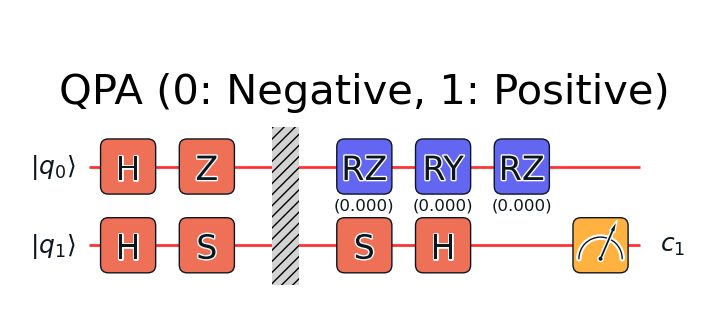

In [7]:
# 3. Drawing circuit diagram

qc.plot_circuit(title="QPA (0: Negative, 1: Positive)")

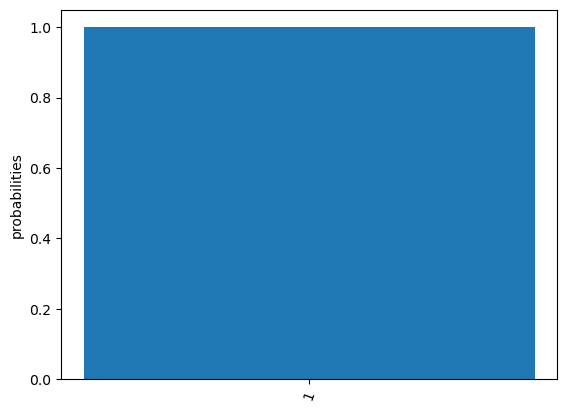

In [8]:
# 4. Simulation and Graph

simu_res = simulate(qc)
simu_res.plot_probabilities()

In [9]:
# Exporting as OpenQASM

qasm = qc.to_openqasm()
print(qasm)

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg meas[2];
h q[0];
z q[0];
h q[1];
s q[1];
barrier q[0],q[1];
rz(0.0) q[0];
ry(0.0) q[0];
rz(0.0) q[0];
s q[1];
h q[1];
measure q[1] -> meas[1];



In [10]:
# Preparing the task
task = {'chip': 'Baihua',  # chip name
        'name': 'QPA',  # task name
        'circuit':qasm, # qasm
        'compile':True
        }

In [11]:
# Sending our task to Quafu's quantum computer
tid = tmgr.run(task)

In [14]:
# Task status
tmgr.status(tid)

'Finished'

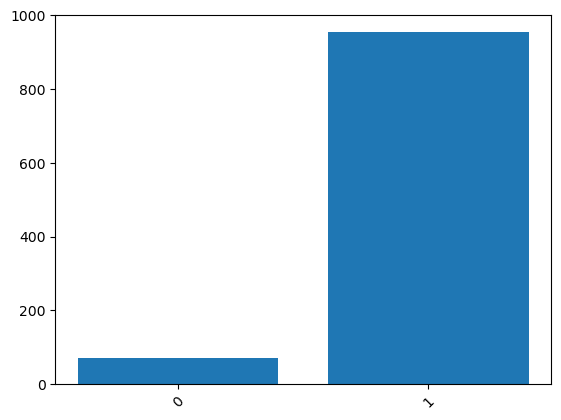

In [15]:
# Graph: The results from quantum computer
res = tmgr.result(tid)
data = res['count']
bases = sorted(data)
count = [data[base] for base in bases]

plt.bar(bases, count)
ticks = plt.xticks(rotation=45)

In [ ]:
Operator	THE GATES
P0+​	    (Empty Circuit) (I)
P1+​	    CNOT(q1​,q0​), then X(q1​)
P2+​	    X(q0​)
P3+​	    CNOT(q1​,q0​), then X(q1​),X(q0​)    
P0−​	    CNOT(q1​,q0​)
P1−​	    X(q1​)
P2−​	    CNOT(q1​,q0​), then X(q0​)
P3−​	    X(q1​),X(q0​)

In [ ]:
"""

#P0+ IDENTITY
U = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]], dtype=complex)

---------------------------------

#P1+
U = np.array([
    [0, 0, 0, 1],
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0]], dtype=complex)

---------------------------------

#P2+
U = np.array([
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [1, 0, 0, 0],
    [0, 1, 0, 0]], dtype=complex)

---------------------------------

#P3+
U = np.array([
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [1, 0, 0, 0]], dtype=complex)

---------------------------------

#P0-
U = np.array([
    [1, 0, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0],
    [0, 1, 0, 0]], dtype=complex)

---------------------------------

#P1-
U = np.array([
    [0, 1, 0, 0],
    [1, 0, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0]], dtype=complex)

---------------------------------

#P2-
U = np.array([
    [0, 0, 1, 0],
    [0, 1, 0, 0],
    [1, 0, 0, 0],
    [0, 0, 0, 1]], dtype=complex)

---------------------------------

#P3-
U = np.array([
    [0, 0, 0, 1],
    [0, 0, 1, 0],
    [0, 1, 0, 0],
    [1, 0, 0, 0]], dtype=complex)

"""